# M4 Recall-Hole Router — Homograph Prospective Expansion + M7 Absorption Breadth

This notebook is a **runnable, annotated demo** of the analysis layer of the experiment
*"M4 Recall-Hole Router: Homograph Prospective Expansion + M7 Absorption Breadth"*.

**The research question.** A single SAE latent is an unreliable unit of analysis (feature
absorption / splitting). The parent project builds **label-free cluster-level units** ("CCRG"
units: a broad *parent* latent plus firing-disjoint *absorber* latents that fill its recall
holes) and asks an *a-priori* question: **can two cheap, label-free firing-structure signals
predict, before any downstream measurement, where grouping will actually help?**

The two signals, read from one forward pass per concept:
* **parent recall-hole** — the fraction of concept-positives the broad parent latent *misses*
  (high ⇒ there are holes for absorbers to fill);
* **firing-Jaccard(detector, parent)** — how firing-disjoint the specialist detector is from the
  parent (low ⇒ narrow, absorbed firing).

The **FROZEN rule** (fit only on 12 *derivation* concepts in iter-5) is:
> predict **absorption-regime** iff `parent recall-hole > tau_h_alone`  (else **co-firing**).

This demo reproduces, on **real precomputed firing-structure signals**, the two headline analyses:
* **M4** — apply the frozen rule *prospectively* to ~90 homograph entities (cities / months /
  given-names / brands), **predict-then-measure**, and decide `ROUTER_VALIDATED` vs `ROUTER_DEMOTED`
  via Wilson 95% CIs;
* **M7** — count how *broad* absorption actually is across the homograph entity space, and name the
  new suppressed-parent homographs.

> **What runs here vs. what was precomputed.** The GPU stage (loading `unsloth/gemma-2-2b` +
> `gemma-scope-2b-pt-res` SAE, encoding corpora, and measuring the per-entity downstream outcome
> `auc_unit` vs `auc_a`) was run once on an NVIDIA L4 and its per-entity outputs are shipped as the
> cards in `mini_demo_data.json`. This notebook replays the **pure-Python router/verdict/breadth
> layer** — the actual methodological contribution — directly on those cards. The frozen-rule
> functions are copied **verbatim** from the experiment's `core.py`.

In [1]:
# --- Dependencies (Colab-safe install pattern) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# This demo only needs numpy + matplotlib, both pre-installed on Colab.
# On Colab: skip (using Colab's versions avoids C-extension ABI corruption).
# Locally: install at Colab's exact versions so the env matches Colab.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors the analysis imports of method.py / core.py) ---
import json, os, math
from collections import defaultdict, Counter

import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True)
print("numpy", np.__version__)

numpy 2.0.2


In [3]:
# --- Data loading helper (GitHub URL with local fallback, for Colab compatibility) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-6/experiment-3/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
cards = data["datasets"][0]["examples"]
ref   = data["metadata"]   # published FULL-run reference (92 homograph entities)

print("loaded", len(cards), "router cards")
print("card kinds:", dict(Counter(c["metadata_kind"] for c in cards)))
print("\npublished full-run reference verdict:", ref["router_verdict"])

loaded 100 router cards
card kinds: {'derivation_concept': 12, 'spelling_prospective': 7, 'homograph_entity': 81}

published full-run reference verdict: ROUTER_DEMOTED


## Configuration

All tunable knobs live here. The two that matter:

* **`TAU_H_GRID_N` / `TAU_J_GRID_N`** — resolution of the threshold sweeps used to *fit* the frozen
  rule on the derivation concepts. The original experiment uses `40` / `34`; those grids contain the
  published optima exactly (`tau_h_alone = 0.7795`, `tau_j = 0.31`), so using them reproduces iter-5
  bit-for-bit. A coarser grid still produces a valid (nearby) rule.
* **`MAX_ENTITY_CARDS`** — cap on how many homograph entity cards to route (0 = all in the subset).

The remaining constants (`SEED`, `MIN_SUB_SENT`, `STABLE_N`, `ABS_HOLE`, `ABS_JAC`, `DERIVATION`,
`NEW_LETTERS`) are copied verbatim from the experiment and define eligibility / structural flags.

In [5]:
# ===== CONFIG — start small; scale up to the originals (see comments) =====
TAU_H_GRID_N    = 40     # recall-hole sweep resolution   (ORIGINAL = 40 -> reproduces tau_h_alone=0.7795)
TAU_J_GRID_N    = 34     # firing-Jaccard sweep resolution (ORIGINAL = 34 -> reproduces tau_j=0.31)
MAX_ENTITY_CARDS = 0     # 0 = route every homograph entity in the subset (ORIGINAL = all)

# ---- constants copied verbatim from core.py / method.py (do not change) ----
SEED          = 1234
MIN_SUB_SENT  = 150      # min diagnostic positives for an entity to be 'eligible' (inferential floor)
STABLE_N      = 30       # M7: min positives for a 'stable' recall-hole estimate
ABS_HOLE      = 0.5      # M7: absorption-structured recall-hole flag
ABS_JAC       = 0.1      # M7: absorption-structured firing-Jaccard flag
NEW_LETTERS   = ["B", "C", "F", "M", "P", "R", "W"]
DERIVATION    = (["spelling_%s" % L for L in ["L", "O", "T", "I", "D"]]
                 + ["numeric", "taxonomic"]
                 + ["toxicity_%s" % s for s in ["threat", "identity_attack", "insult",
                                                "obscene", "sexual_explicit"]])
PRIOR_NAMED_SUPPRESSED = ["Georgia", "Jordan"]   # taxonomic-set homographs, not new here
HIERARCHIES   = ["city", "month", "given_name", "brand"]

# threshold grids built from the config (same endpoints as core.py)
TAU_J_GRID = np.linspace(0.02, 0.35, TAU_J_GRID_N)
TAU_H_GRID = np.linspace(0.0,  0.95, TAU_H_GRID_N)
print("TAU_H_GRID:", TAU_H_GRID_N, "points in [0.00, 0.95]")
print("TAU_J_GRID:", TAU_J_GRID_N, "points in [0.02, 0.35]")

TAU_H_GRID: 40 points in [0.00, 0.95]
TAU_J_GRID: 34 points in [0.02, 0.35]


## The frozen-rule functions (copied **verbatim** from `core.py`)

These are the iter-5 router primitives — the heart of the method. They are pure NumPy/Python (no GPU,
no model). `derive_single` / `derive_combined` *fit* thresholds by a balanced-accuracy sweep with a
max-min-margin tie-break; `predict_*` apply a frozen threshold; `wilson_ci` is the small-`n`-honest
binomial CI used for the verdict; `loo_*` are leave-one-concept-out checks.

In [6]:
# ----- copied verbatim from core.py (firing-structure router primitives) -----
def wilson_ci(hits, n, z=1.959963984540054):
    """Wilson score 95% CI for a binomial proportion (hits/n). Honest for small n."""
    if n == 0:
        return dict(hits=0, n=0, rate=float("nan"), wilson_ci=[float("nan"), float("nan")])
    p = hits / n
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return dict(hits=int(hits), n=int(n), rate=float(p),
                wilson_ci=[float(max(0.0, centre - half)), float(min(1.0, centre + half))])


def balanced_accuracy(pred, truth):
    pred = np.asarray(pred); truth = np.asarray(truth)
    accs = []
    for cls in ["absorption", "co_firing"]:
        m = truth == cls
        if m.sum() == 0:
            continue
        accs.append((pred[m] == cls).mean())
    return float(np.mean(accs)) if accs else float("nan")


def derive_single(concepts, key, lt, grid, truth_key="ground_truth_regime"):
    """Single-threshold router on `key` over an explicit `grid` (absorption iff value < tau when lt
    else value > tau). Tie-break = threshold most central in the optimal plateau (max min-margin)."""
    vals = np.array([c[key] for c in concepts], float)
    truth = np.array([c[truth_key] for c in concepts])
    if len(vals) == 0 or not np.isfinite(vals).any():
        return float("nan"), float("nan"), []
    sweep = []
    for tau in grid:
        pred = np.where(vals < tau if lt else vals > tau, "absorption", "co_firing")
        margins = []
        for v, y in zip(vals, truth):
            pr = "absorption" if (v < tau if lt else v > tau) else "co_firing"
            d = (tau - v) if lt else (v - tau)
            margins.append((abs(d) if pr == y else -abs(d)))
        sweep.append(dict(tau=float(tau), balanced_acc=balanced_accuracy(pred, truth),
                          margin=float(min(margins)) if len(margins) else float("-inf")))
    best = max(sweep, key=lambda r: (r["balanced_acc"], r["margin"]))
    return best["tau"], best["balanced_acc"], sweep


def _jh_truth(concepts, truth_key="ground_truth_regime"):
    j = np.array([c["jaccard_median"] for c in concepts], float)
    h = np.array([c["recall_hole_max"] for c in concepts], float)
    truth = np.array([c[truth_key] for c in concepts])
    return j, h, truth


def _combined_margin(j, h, truth, tj, th):
    margins = []
    for ji, hi, yi in zip(j, h, truth):
        in_box = (ji < tj) and (hi > th)
        if yi == "absorption":
            m = min(tj - ji, hi - th)
        else:
            m = max(ji - tj, th - hi)
        margins.append(m if (in_box == (yi == "absorption")) else -abs(m) - 1e-9)
    return float(min(margins)) if margins else float("-inf")


def derive_combined(concepts, tj_grid, th_grid, truth_key="ground_truth_regime"):
    """LEAD router: predict absorption iff (firing-Jaccard < tau_j) AND (recall_hole_max > tau_h)."""
    j, h, truth = _jh_truth(concepts, truth_key)
    if len(j) == 0:
        return dict(tau_j=float("nan"), tau_h=float("nan"), balanced_acc=float("nan"),
                    margin=float("nan"), n_optimal_cells=0, degenerate_tau_h=None)
    best = None
    for tj in tj_grid:
        for th in th_grid:
            pred = np.where((j < tj) & (h > th), "absorption", "co_firing")
            ba = balanced_accuracy(pred, truth)
            mg = _combined_margin(j, h, truth, float(tj), float(th))
            cand = (ba, mg)
            if best is None or cand > (best["balanced_acc"], best["margin"]):
                best = dict(tau_j=float(tj), tau_h=float(th), balanced_acc=float(ba), margin=float(mg))
    return best


def predict_combined(c, tau_j, tau_h):
    return ("absorption" if (np.isfinite(tau_j) and np.isfinite(tau_h)
                             and c["jaccard_median"] < tau_j and c["recall_hole_max"] > tau_h)
            else "co_firing")


def predict_recall_hole_alone(c, tau_h_alone):
    """PRIMARY rule: predict absorption iff parent recall-hole exceeds tau_h_alone."""
    return ("absorption" if (np.isfinite(tau_h_alone) and np.isfinite(c["recall_hole_max"])
                             and c["recall_hole_max"] > tau_h_alone) else "co_firing")


def predict_jaccard_alone(c, tau_j_alone):
    return ("absorption" if (np.isfinite(tau_j_alone) and np.isfinite(c["jaccard_median"])
                             and c["jaccard_median"] < tau_j_alone) else "co_firing")


def loo_single(concepts, key, lt, grid, truth_key="ground_truth_regime"):
    """Leave-one-derivation-concept-out for a single-signal rule (refit tau on N-1, predict held-out)."""
    rows = []
    for i, ci in enumerate(concepts):
        rest = [c for k, c in enumerate(concepts) if k != i]
        if len(set(c[truth_key] for c in rest)) < 2:
            tau, _, _ = derive_single(concepts, key, lt, grid, truth_key)
        else:
            tau, _, _ = derive_single(rest, key, lt, grid, truth_key)
        v = float(ci[key])
        pred = "absorption" if (np.isfinite(tau) and (v < tau if lt else v > tau)) else "co_firing"
        rows.append(dict(concept=ci["concept"], tau_fold=float(tau), pred=pred,
                         ground_truth=ci[truth_key], hit=bool(pred == ci[truth_key])))
    acc = float(np.mean([r["hit"] for r in rows])) if rows else float("nan")
    return acc, rows

print("frozen-rule primitives loaded")

frozen-rule primitives loaded


## Step 1 — reconstruct the concept / entity rows from the precomputed cards

Each card already carries the label-free signals (`recall_hole`, `jaccard`) and the measured
downstream outcome (`auc_unit`, `auc_a`, `delta_vs_a`, `ground_truth_regime`). We split the cards
into the three roles the method uses:

* **derivation** (12 concepts) — where the frozen rule is fit; *never* counted prospective;
* **spelling-prospective** (7 new letters) — truly held-out spelling concepts;
* **homograph entities** (cities / months / given-names / brands) — the prospective expansion.

In [7]:
def card_to_concept(c):
    # map a derivation/spelling card to the {jaccard_median, recall_hole_max, ...} row the router expects
    return dict(concept=c["metadata_concept"],
                jaccard_median=c["metadata_jaccard"],
                recall_hole_max=c["metadata_recall_hole"],
                ground_truth_regime=c["metadata_ground_truth_regime"],
                ground_truth_regime_vs_h=c["metadata_ground_truth_regime_vs_h"],
                auc_unit=c["metadata_outcome_auc_unit"],
                auc_a=c["metadata_outcome_auc_a_rawlatent"],
                delta_vs_a=c["metadata_outcome_delta_vs_a"],
                role=c["metadata_role"])

derivation = [card_to_concept(c) for c in cards if c["metadata_kind"] == "derivation_concept"]
spelling   = [card_to_concept(c) for c in cards if c["metadata_kind"] == "spelling_prospective"]

entity_cards = [c for c in cards if c["metadata_kind"] == "homograph_entity"]
if MAX_ENTITY_CARDS:
    entity_cards = entity_cards[:MAX_ENTITY_CARDS]

def card_to_entity(c):
    return dict(hierarchy=c["metadata_hierarchy"], entity=c["metadata_entity"],
                n_all=c["metadata_n_all"], n_diag=c["metadata_n_diagnostic"],
                eligible=bool(c["metadata_eligible"]), power_flag=c["metadata_power_flag"],
                recall_hole=c["metadata_recall_hole"], jaccard=c["metadata_jaccard"],
                homograph_strength=c["metadata_homograph_strength"],
                competitor_sense=c["metadata_competitor_sense"],
                ground_truth_regime=c["metadata_ground_truth_regime"],
                ground_truth_regime_vs_h=c["metadata_ground_truth_regime_vs_h"],
                auc_unit=c["metadata_outcome_auc_unit"], auc_a=c["metadata_outcome_auc_a_rawlatent"],
                auc_h=c["metadata_outcome_auc_h_attribution"], auc_d=c["metadata_outcome_auc_d_nonsae"],
                delta_vs_a=c["metadata_outcome_delta_vs_a"])

entity_rows = [card_to_entity(c) for c in entity_cards]

print("derivation concepts :", len(derivation))
print("spelling prospective:", len(spelling))
print("homograph entities  :", len(entity_rows),
      "  (eligible:", sum(e["eligible"] for e in entity_rows), ")")
print("\nby hierarchy:", dict(Counter(e["hierarchy"] for e in entity_rows)))

derivation concepts : 12
spelling prospective: 7
homograph entities  : 81   (eligible: 34 )

by hierarchy: {'city': 23, 'month': 12, 'given_name': 33, 'brand': 13}


## Step 2 — fit the FROZEN rule on the 12 derivation concepts

`tau_h_alone` (PRIMARY) is fit by a recall-hole balanced-accuracy sweep; the combined `(tau_j, tau_h)`
and the jaccard-alone `tau_j_alone` are the ablations. The frozen rule is then locked **before** any
prospective outcome is touched. We compare to the published iter-5 reference
(`tau_h_alone = 0.7795`, derivation balanced-accuracy `1.0`, LOO `0.833`).

In [8]:
# fit the PRIMARY recall-hole-alone threshold + the two ablations, on derivation ONLY
th_alone, bacc_h, _ = derive_single(derivation, "recall_hole_max", False, TAU_H_GRID)
tj_alone, bacc_j, _ = derive_single(derivation, "jaccard_median",  True,  TAU_J_GRID)
frozen = derive_combined(derivation, TAU_J_GRID, TAU_H_GRID)
FROZEN = dict(tau_j=frozen["tau_j"], tau_h=frozen["tau_h"],
              tau_h_alone=th_alone, tau_j_alone=tj_alone)

loo_h_acc, _ = loo_single(derivation, "recall_hole_max", False, TAU_H_GRID)

print("FROZEN PRIMARY rule:  predict ABSORPTION iff parent recall-hole > %.4f" % th_alone)
print("  derivation balanced-acc (recall-hole-alone): %.3f" % bacc_h)
print("  LOO (recall-hole-alone)                    : %.3f" % loo_h_acc)
print("  combined ablation: tau_j=%.3f tau_h=%.3f (bacc %.3f)"
      % (frozen["tau_j"], frozen["tau_h"], frozen["balanced_acc"]))
print("  jaccard-alone ablation: tau_j_alone=%.3f (bacc %.3f)" % (tj_alone, bacc_j))

ref_fr = ref["frozen_rule"]
print("\nreproduction check vs published iter-5 reference:")
print("  tau_h_alone : demo %.4f  |  reference %.4f  |  drift %.2e"
      % (th_alone, ref_fr["tau_h_alone"], abs(th_alone - ref_fr["tau_h_alone"])))
print("  derivation bacc : demo %.3f  |  reference %.3f" % (bacc_h, ref_fr["derivation_balanced_acc"]))

FROZEN PRIMARY rule:  predict ABSORPTION iff parent recall-hole > 0.7795
  derivation balanced-acc (recall-hole-alone): 1.000
  LOO (recall-hole-alone)                    : 0.833
  combined ablation: tau_j=0.310 tau_h=0.779 (bacc 1.000)
  jaccard-alone ablation: tau_j_alone=0.050 (bacc 0.917)

reproduction check vs published iter-5 reference:
  tau_h_alone : demo 0.7795  |  reference 0.7795  |  drift 0.00e+00
  derivation bacc : demo 1.000  |  reference 1.000


## Step 3 — predict-then-measure on the prospective set

For every prospective concept/entity we (1) **PREDICT** its regime with the frozen rule from its
label-free signals, then (2) compare to the **measured** ground truth
`sign(auc_unit - auc_a)` (does the label-free grouped unit beat the best raw SAE latent?).
A *hit* means the router called it correctly. We also recompute the M7 structural flag
`absorption_structured = (recall_hole > ABS_HOLE) and (jaccard < ABS_JAC)`.

In [9]:
def route(c_signals, ground_truth, ground_truth_vs_h):
    # apply the frozen rule (PRIMARY + two ablations) and score the hit against measured truth
    pr      = predict_recall_hole_alone(c_signals, FROZEN["tau_h_alone"])   # PRIMARY
    pr_comb = predict_combined(c_signals, FROZEN["tau_j"], FROZEN["tau_h"])
    pr_jac  = predict_jaccard_alone(c_signals, FROZEN["tau_j_alone"])
    return dict(predicted_regime=pr, predicted_regime_combined=pr_comb,
                predicted_regime_jaccard=pr_jac,
                hit_vs_a=bool(pr == ground_truth),
                hit_vs_a_combined=bool(pr_comb == ground_truth),
                hit_vs_a_jaccard=bool(pr_jac == ground_truth),
                hit_vs_h=bool(pr == ground_truth_vs_h))

# --- spelling prospective ---
for r in spelling:
    sig = {"jaccard_median": r["jaccard_median"], "recall_hole_max": r["recall_hole_max"]}
    r.update(route(sig, r["ground_truth_regime"], r["ground_truth_regime_vs_h"]))

# --- homograph entities (predict-then-measure, logged like the audit trail) ---
for e in entity_rows:
    sig = {"jaccard_median": e["jaccard"], "recall_hole_max": e["recall_hole"]}
    e.update(route(sig, e["ground_truth_regime"], e["ground_truth_regime_vs_h"]))
    e["absorption_structured"] = bool(e["recall_hole"] > ABS_HOLE and e["jaccard"] < ABS_JAC)

# show a few predict-then-measure rows
print("%-10s %-9s %8s %8s   %-11s -> %-11s  %s" %
      ("hier", "entity", "recallH", "jaccard", "PREDICT", "truth", "hit"))
for e in entity_rows[:12]:
    print("%-10s %-9s %8.3f %8.3f   %-11s -> %-11s  %s" %
          (e["hierarchy"], e["entity"], e["recall_hole"], e["jaccard"],
           e["predicted_regime"], e["ground_truth_regime"], e["hit_vs_a"]))

hier       entity     recallH  jaccard   PREDICT     -> truth        hit
city       Bath         0.040    0.101   co_firing   -> co_firing    True
city       Bend         0.090    0.074   co_firing   -> co_firing    True
city       Buffalo      0.067    0.126   co_firing   -> co_firing    True
city       Cleveland    0.100    0.136   co_firing   -> co_firing    True
city       Cologne      0.020    0.187   co_firing   -> co_firing    True
city       Columbus     0.117    0.142   co_firing   -> co_firing    True
city       Cork         0.110    0.291   co_firing   -> co_firing    True
city       Florence     0.033    0.126   co_firing   -> co_firing    True
city       Hollywood    0.040    0.206   co_firing   -> co_firing    True
city       Hull         0.033    0.098   co_firing   -> co_firing    True
city       Jackson      0.070    0.141   co_firing   -> co_firing    True
city       Jordan       0.037    0.177   co_firing   -> co_firing    True


## Step 4 — M4 verdict: stratified prospective hit-rate + Wilson CIs

We stratify the **eligible** (inferential, `n_diag >= MIN_SUB_SENT`) entities by their *predicted*
regime and compute a Wilson 95% CI of the hit-rate in each stratum. The router is **VALIDATED** only
if a prospective absorption-predicted CI **excludes 0.5** (better than chance at calling where
grouping helps); otherwise it is honestly **DEMOTED** to an exploratory diagnostic.

The aggregation logic below (`strat`, `_excludes_half`, the verdict) is copied from `method.py`'s
`aggregate_and_verdict`.

In [10]:
def _excludes_half(ci):
    lo, hi = ci["wilson_ci"]
    return (lo is not None and lo > 0.5) or (hi is not None and hi < 0.5)

def strat(rows, pred_key, hit_key):
    absn = [r for r in rows if r[pred_key] == "absorption"]
    cof  = [r for r in rows if r[pred_key] == "co_firing"]
    return dict(absorption_predicted=wilson_ci(sum(1 for r in absn if r[hit_key]), len(absn)),
                cofiring_predicted=wilson_ci(sum(1 for r in cof if r[hit_key]), len(cof)),
                combined_all=wilson_ci(sum(1 for r in rows if r[hit_key]), len(rows)))

inf = [e for e in entity_rows if e["eligible"]]   # inferential stratum drives the verdict
php = strat(inf, "predicted_regime", "hit_vs_a")

# combine homograph absorption-predicted entities WITH the 7 spelling letters to maximize the
# absorption arm's n (best chance to exclude 0.5)
sp_abs   = [r for r in spelling if r.get("predicted_regime") == "absorption"]
abs_inf  = [r for r in inf if r["predicted_regime"] == "absorption"]
hits_plus = sum(1 for r in abs_inf if r["hit_vs_a"]) + sum(1 for r in sp_abs if r["hit_vs_a"])
n_plus    = len(abs_inf) + len(sp_abs)
wilson_abs_plus = wilson_ci(hits_plus, n_plus)

wilson_abs = php["absorption_predicted"]
verdict = ("ROUTER_VALIDATED" if (_excludes_half(wilson_abs) or _excludes_half(wilson_abs_plus))
           else "ROUTER_DEMOTED")

def fmt(ci): return "%d/%d (rate=%.3f, Wilson95=[%.3f, %.3f])" % (
    ci["hits"], ci["n"], ci["rate"], ci["wilson_ci"][0], ci["wilson_ci"][1])

print("PROSPECTIVE hit-rate by PRIMARY predicted regime (inferential homograph entities):")
print("  co_firing-predicted   :", fmt(php["cofiring_predicted"]))
print("  absorption-predicted  :", fmt(php["absorption_predicted"]))
print("  absorption + spelling :", fmt(wilson_abs_plus))
print("\n>>> M4 VERDICT =", verdict)
print("    (validated iff some absorption-predicted Wilson CI excludes 0.5)")
print("\npublished full-run verdict:", ref["router_verdict"])

PROSPECTIVE hit-rate by PRIMARY predicted regime (inferential homograph entities):
  co_firing-predicted   : 29/30 (rate=0.967, Wilson95=[0.833, 0.994])
  absorption-predicted  : 2/4 (rate=0.500, Wilson95=[0.150, 0.850])
  absorption + spelling : 5/10 (rate=0.500, Wilson95=[0.237, 0.763])

>>> M4 VERDICT = ROUTER_DEMOTED
    (validated iff some absorption-predicted Wilson CI excludes 0.5)

published full-run verdict: ROUTER_DEMOTED


## Step 5 — M7 absorption breadth count

How *narrow* is absorption across the homograph entity space? We count entities with a **stable**
estimate (`n_all >= STABLE_N`) that are **absorption-structured** (`recall_hole > 0.5` and
`firing-Jaccard < 0.1`), break it down per hierarchy, and name the **new suppressed-parent
homographs** (beyond Georgia/Jordan, which live in the taxonomic derivation set). We also report the
**downstream-confirmed** absorption entities — those where the label-free unit *actually* beats the
best raw latent (`ground_truth_regime == absorption`), which is a different lens from the structural
flag.

In [11]:
stable          = [e for e in entity_rows if e["n_all"] >= STABLE_N]
abs_struct      = sorted([e for e in stable if e["absorption_structured"]],
                         key=lambda e: -e["recall_hole"])
new_suppressed  = [e for e in abs_struct if e["entity"] not in PRIOR_NAMED_SUPPRESSED]
downstream_abs  = sorted([e for e in entity_rows if e["ground_truth_regime"] == "absorption"],
                         key=lambda e: -e["delta_vs_a"])

per_hier = {}
for h in HIERARCHIES:
    hs = [e for e in stable if e["hierarchy"] == h]
    per_hier[h] = (len(hs), sum(e["absorption_structured"] for e in hs))

print("M7 BREADTH")
print("  homograph entities with stable estimate (n_all>=%d): %d" % (STABLE_N, len(stable)))
print("  absorption-structured (recall_hole>%.1f AND jaccard<%.1f): %d"
      % (ABS_HOLE, ABS_JAC, len(abs_struct)))
print("\n  per hierarchy (stable -> absorption-structured):")
for h in HIERARCHIES:
    print("    %-10s : %2d -> %d" % (h, per_hier[h][0], per_hier[h][1]))

print("\n  NEW named suppressed-parent homographs:")
for e in new_suppressed:
    print("    %-8s (%s)  recall_hole=%.3f jaccard=%.3f  competitor='%s'"
          % (e["entity"], e["hierarchy"], e["recall_hole"], e["jaccard"], e["competitor_sense"]))

print("\n  DOWNSTREAM-confirmed absorption (label-free unit beats best raw latent a):")
for e in downstream_abs[:6]:
    print("    %-8s (%s)  delta_vs_a=%+.3f  recall_hole=%.3f jaccard=%.3f  struct=%s"
          % (e["entity"], e["hierarchy"], e["delta_vs_a"], e["recall_hole"],
             e["jaccard"], e["absorption_structured"]))
print("\n  STRUCTURAL != DOWNSTREAM: structurally-shaped months can be co_firing downstream, and the")
print("  strongest downstream winner (May) has HIGH firing-Jaccard yet a real grouping benefit.")

M7 BREADTH
  homograph entities with stable estimate (n_all>=30): 64
  absorption-structured (recall_hole>0.5 AND jaccard<0.1): 3

  per hierarchy (stable -> absorption-structured):
    city       : 22 -> 0
    month      : 12 -> 3
    given_name : 20 -> 0
    brand      : 10 -> 0

  NEW named suppressed-parent homographs:
    March    (month)  recall_hole=0.997 jaccard=0.075  competitor='to march / a protest march'
    June     (month)  recall_hole=0.947 jaccard=0.006  competitor='given name'
    February (month)  recall_hole=0.573 jaccard=0.053  competitor='non-month sense of 'february''

  DOWNSTREAM-confirmed absorption (label-free unit beats best raw latent a):
    May      (month)  delta_vs_a=+0.160  recall_hole=0.980 jaccard=0.434  struct=False
    Carol    (given_name)  delta_vs_a=+0.014  recall_hole=0.015 jaccard=0.285  struct=False
    November (month)  delta_vs_a=+0.000  recall_hole=0.000 jaccard=0.298  struct=False
    April    (month)  delta_vs_a=+0.000  recall_hole=0.997 

## Results — visualization

* **Left:** the label-free signal plane (parent recall-hole vs firing-Jaccard) for every prospective
  homograph entity, coloured by *measured* regime. The dashed line is the frozen `tau_h_alone`; the
  shaded box is the M7 absorption-structured region. The months sit in the high-recall-hole tail.
* **Right:** prospective hit-rate by predicted stratum with Wilson 95% CIs; the chance line at 0.5 is
  the bar for the verdict — co-firing-predicted clears it, absorption-predicted does not (hence
  `ROUTER_DEMOTED`).

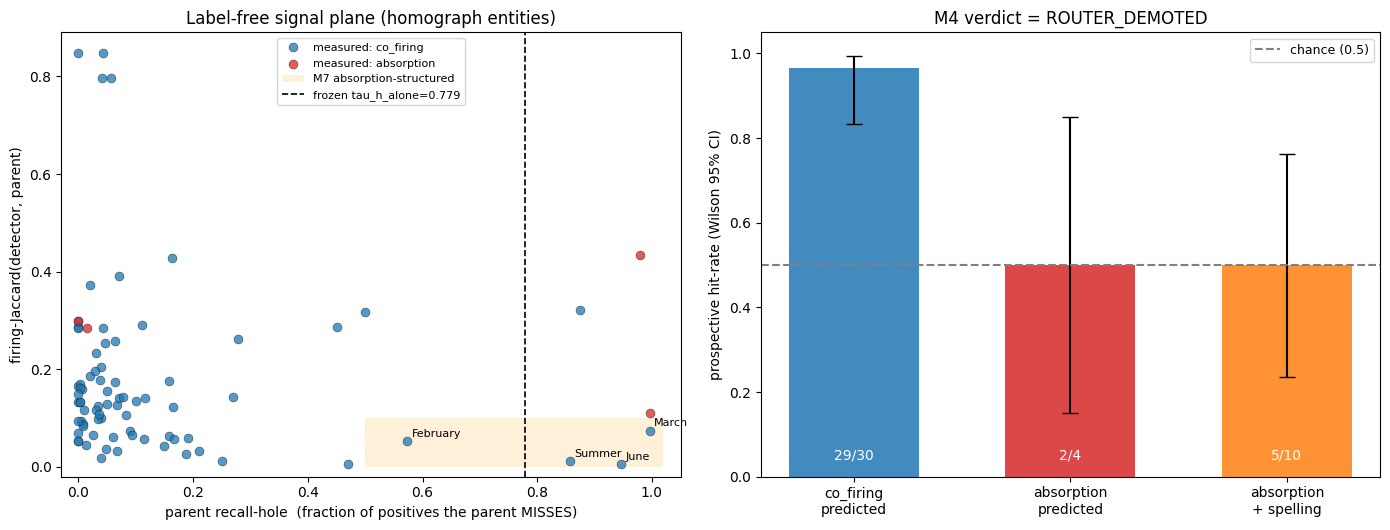

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.4))

# ---- (left) signal plane ----
colors = {"absorption": "#d62728", "co_firing": "#1f77b4"}
for reg in ("co_firing", "absorption"):
    pts = [e for e in entity_rows if e["ground_truth_regime"] == reg]
    ax1.scatter([e["recall_hole"] for e in pts], [e["jaccard"] for e in pts],
                c=colors[reg], s=42, alpha=0.75, edgecolors="k", linewidths=0.3,
                label="measured: %s" % reg)
# M7 absorption-structured box (recall_hole > ABS_HOLE, jaccard < ABS_JAC)
ax1.add_patch(plt.Rectangle((ABS_HOLE, 0.0), 1.02 - ABS_HOLE, ABS_JAC,
                            facecolor="orange", alpha=0.15, zorder=0,
                            label="M7 absorption-structured"))
ax1.axvline(FROZEN["tau_h_alone"], ls="--", c="k", lw=1.2,
            label="frozen tau_h_alone=%.3f" % FROZEN["tau_h_alone"])
for e in entity_rows:
    if e["absorption_structured"]:
        ax1.annotate(e["entity"], (e["recall_hole"], e["jaccard"]),
                     fontsize=8, xytext=(3, 3), textcoords="offset points")
ax1.set_xlabel("parent recall-hole  (fraction of positives the parent MISSES)")
ax1.set_ylabel("firing-Jaccard(detector, parent)")
ax1.set_title("Label-free signal plane (homograph entities)")
ax1.set_xlim(-0.03, 1.05); ax1.set_ylim(-0.02, max(0.5, min(1.0, ax1.get_ylim()[1])))
ax1.legend(fontsize=8, loc="upper center")

# ---- (right) prospective hit-rate by stratum with Wilson CIs ----
bars = [("co_firing\npredicted", php["cofiring_predicted"]),
        ("absorption\npredicted", php["absorption_predicted"]),
        ("absorption\n+ spelling", wilson_abs_plus)]
xs = np.arange(len(bars))
rates = [b[1]["rate"] for b in bars]
los = [b[1]["rate"] - b[1]["wilson_ci"][0] for b in bars]
his = [b[1]["wilson_ci"][1] - b[1]["rate"] for b in bars]
bcol = ["#1f77b4", "#d62728", "#ff7f0e"]
ax2.bar(xs, rates, color=bcol, alpha=0.85, width=0.6)
ax2.errorbar(xs, rates, yerr=[los, his], fmt="none", ecolor="k", capsize=6, lw=1.5)
ax2.axhline(0.5, ls="--", c="gray", label="chance (0.5)")
for x, b in zip(xs, bars):
    ax2.text(x, 0.04, "%d/%d" % (b[1]["hits"], b[1]["n"]), ha="center", fontsize=10, color="white")
ax2.set_xticks(xs); ax2.set_xticklabels([b[0] for b in bars])
ax2.set_ylim(0, 1.05); ax2.set_ylabel("prospective hit-rate (Wilson 95% CI)")
ax2.set_title("M4 verdict = %s" % verdict)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Summary

A compact recap of everything the demo recomputed, next to the published full-run reference.

In [13]:
print("="*72)
print("M4 / M7 ROUTER DEMO — SUMMARY")
print("="*72)
print("FROZEN rule        : predict ABSORPTION iff parent recall-hole > %.4f" % FROZEN["tau_h_alone"])
print("  derivation bacc  : %.3f   LOO : %.3f   (iter-5 ref %.4f / %.3f / 0.833)"
      % (bacc_h, loo_h_acc, ref["frozen_rule"]["tau_h_alone"], ref["frozen_rule"]["derivation_balanced_acc"]))
print("-"*72)
print("M4  prospective inferential entities : %d  (eligible of %d total)"
      % (len(inf), len(entity_rows)))
print("    co_firing-predicted  hit-rate    :", fmt(php["cofiring_predicted"]))
print("    absorption-predicted hit-rate    :", fmt(php["absorption_predicted"]))
print("    VERDICT (demo)                   :", verdict)
print("    VERDICT (published full run)     :", ref["router_verdict"])
print("-"*72)
print("M7  stable entities (n_all>=%d)       : %d" % (STABLE_N, len(stable)))
print("    absorption-structured            : %d  (%s)"
      % (len(abs_struct), ", ".join(e["entity"] for e in abs_struct)))
print("    new suppressed-parent homographs : %s" % ", ".join(e["entity"] for e in new_suppressed))
print("    strongest downstream win         : %s/%s  delta_vs_a=%+.3f"
      % (downstream_abs[0]["hierarchy"], downstream_abs[0]["entity"], downstream_abs[0]["delta_vs_a"]))
print("="*72)

M4 / M7 ROUTER DEMO — SUMMARY
FROZEN rule        : predict ABSORPTION iff parent recall-hole > 0.7795
  derivation bacc  : 1.000   LOO : 0.833   (iter-5 ref 0.7795 / 1.000 / 0.833)
------------------------------------------------------------------------
M4  prospective inferential entities : 34  (eligible of 81 total)
    co_firing-predicted  hit-rate    : 29/30 (rate=0.967, Wilson95=[0.833, 0.994])
    absorption-predicted hit-rate    : 2/4 (rate=0.500, Wilson95=[0.150, 0.850])
    VERDICT (demo)                   : ROUTER_DEMOTED
    VERDICT (published full run)     : ROUTER_DEMOTED
------------------------------------------------------------------------
M7  stable entities (n_all>=30)       : 64
    absorption-structured            : 3  (March, June, February)
    new suppressed-parent homographs : March, June, February
    strongest downstream win         : month/May  delta_vs_a=+0.160
